In [1]:
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
import numpy as np
from tqdm.auto import tqdm
import math

In [2]:
dataset = load_dataset("Suryanshg/SUPER-NATURALINSTRUCTIONS-xlingual", streaming=True)


dataset

IterableDatasetDict({
    train: IterableDataset({
        features: ['task_name', 'instruction', 'input_language', 'output_language', 'instruction_language', 'categories', 'input', 'output'],
        num_shards: 10
    })
    test: IterableDataset({
        features: ['task_name', 'instruction', 'input_language', 'output_language', 'instruction_language', 'categories', 'input', 'output'],
        num_shards: 1
    })
})

In [3]:
# Get Unique Training Tasks
train_tasks_only = dataset['train'].select_columns(['task_name'])
unique_train_tasks = set(item['task_name'] for item in train_tasks_only)

print("--- TRAIN SPLIT ---")
print(f"Total unique tasks: {len(unique_train_tasks)}")

# Get Unique Testing Tasks
test_tasks_only = dataset['test'].select_columns(['task_name'])
unique_test_tasks = set(item['task_name'] for item in test_tasks_only)

print("--- TEST SPLIT ---")
print(f"Total unique tasks: {len(unique_test_tasks)}")

--- TRAIN SPLIT ---
Total unique tasks: 1270
--- TEST SPLIT ---
Total unique tasks: 35


In [4]:
def find_tasks_with_multiple_outs_per_instance(split):
    seen_pairs = set()
    tasks_with_duplicates = set()

    # Only stream the columns we need to save bandwidth and parsing time
    train_subset = dataset[split].select_columns(['task_name', 'input'])

    # Iterate through the streaming dataset in batches for much better performance
    for batch in train_subset.iter(batch_size=1000):
        # Iterate over the zipped columns within the current batch
        for task, inp in zip(batch['task_name'], batch['input']):
            # Minor optimization: if we already know this task has duplicates, skip checking
            if task in tasks_with_duplicates:
                continue
                
            pair = (task, inp)
            if pair in seen_pairs:
                # If we've seen this exact task + input combination before, it's a duplicate
                tasks_with_duplicates.add(task)
            else:
                seen_pairs.add(pair)

    print(f"\n--- {split.upper()} SPLIT ---")
    print(f"Tasks with at least one duplicate input: {len(tasks_with_duplicates)}")
    return tasks_with_duplicates

train_tasks_with_duplicates = find_tasks_with_multiple_outs_per_instance("train")
test_tasks_with_duplicates = find_tasks_with_multiple_outs_per_instance("test")


--- TRAIN SPLIT ---
Tasks with at least one duplicate input: 112

--- TEST SPLIT ---
Tasks with at least one duplicate input: 3


### Regexes for Finding Instances with multiple outputs
```
"output":\s*\[\n\s*"[\w\s*]*",
"output":\s*\[\n\s*"[\w\s*?]*",
```


In [5]:
train_tasks_with_duplicates

{'task001_quoref_question_generation',
 'task002_quoref_answer_generation',
 'task023_cosmosqa_question_generation',
 'task024_cosmosqa_answer_generation',
 'task025_cosmosqa_incorrect_answer_generation',
 'task026_drop_question_generation',
 'task028_drop_answer_generation',
 'task043_essential_terms_answering_incomplete_questions',
 'task044_essential_terms_identifying_essential_words',
 'task045_miscellaneous_sentence_paraphrasing',
 'task046_miscellaneous_question_typing',
 'task059_ropes_story_generation',
 'task060_ropes_question_generation',
 'task067_abductivenli_answer_generation',
 'task068_abductivenli_incorrect_answer_generation',
 'task074_squad1.1_question_generation',
 'task075_squad1.1_answer_generation',
 'task082_babi_t1_single_supporting_fact_question_generation',
 'task1087_two_number_sum',
 'task108_contextualabusedetection_classification',
 'task111_asset_sentence_simplification',
 'task1217_atomic_answer_generation',
 'task127_scan_long_text_generation_action_com

In [6]:
test_tasks_with_duplicates

{'task396_persianqa_classification',
 'task463_parsinlu_entailment_classification',
 'task464_parsinlu_entailment_sentence_generation'}

### Instruction Language Analysis

In [7]:
def analyze_instruction_language(split):
    language_counts = Counter()
    
    # Select only the column we need for performance
    subset = dataset[split].select_columns(['instruction_language'])
    
    print(f"Fetching language distribution for {split} split...")
    
    # Iterate through the streaming dataset in batches
    for batch in subset.iter(batch_size=1000):
        # Update the counter with the list of languages in the current batch
        language_counts.update(batch['instruction_language'])
        
    print(f"\n--- {split.upper()} SPLIT LANGUAGE DISTRIBUTION ---")
    total_samples = sum(language_counts.values())
    
    for lang, count in language_counts.most_common():
        percentage = (count / total_samples) * 100
        print(f"{lang}: {count} ({percentage:.2f}%)")
        
    return language_counts

# Run the analysis on both splits
train_langs = analyze_instruction_language("train")
test_langs = analyze_instruction_language("test")

Fetching language distribution for train split...

--- TRAIN SPLIT LANGUAGE DISTRIBUTION ---
English: 4902436 (100.00%)
Fetching language distribution for test split...

--- TEST SPLIT LANGUAGE DISTRIBUTION ---
English: 36432 (100.00%)


### Distribution of Categories

Fetching category distribution for train split...

--- TRAIN SPLIT CATEGORY TOP 50 ---
Translation: 1253159 (25.56%)
Question Generation: 458931 (9.36%)
Program Execution: 433873 (8.85%)
Question Answering: 412346 (8.41%)
Sentence Perturbation: 313623 (6.40%)
Sentiment Analysis: 211809 (4.32%)
Wrong Candidate Generation: 163798 (3.34%)
Text Matching: 136323 (2.78%)
Commonsense Classification: 130257 (2.66%)
Misc.: 121155 (2.47%)
Text Categorization: 117813 (2.40%)
Toxic Language Detection: 115591 (2.36%)
Story Composition: 75267 (1.54%)
Question Understanding: 70028 (1.43%)
Pos Tagging: 62118 (1.27%)
Fill in The Blank: 55783 (1.14%)
Information Extraction: 51148 (1.04%)
Text to Code: 49441 (1.01%)
Linguistic Probing: 47482 (0.97%)
Text Completion: 47145 (0.96%)
Dialogue Generation: 45381 (0.93%)
Language Identification: 43237 (0.88%)
Summarization: 43182 (0.88%)
Code to Text: 40040 (0.82%)
Text Simplification: 37345 (0.76%)
Mathematics: 30317 (0.62%)
Coherence Classification: 30077 (0.

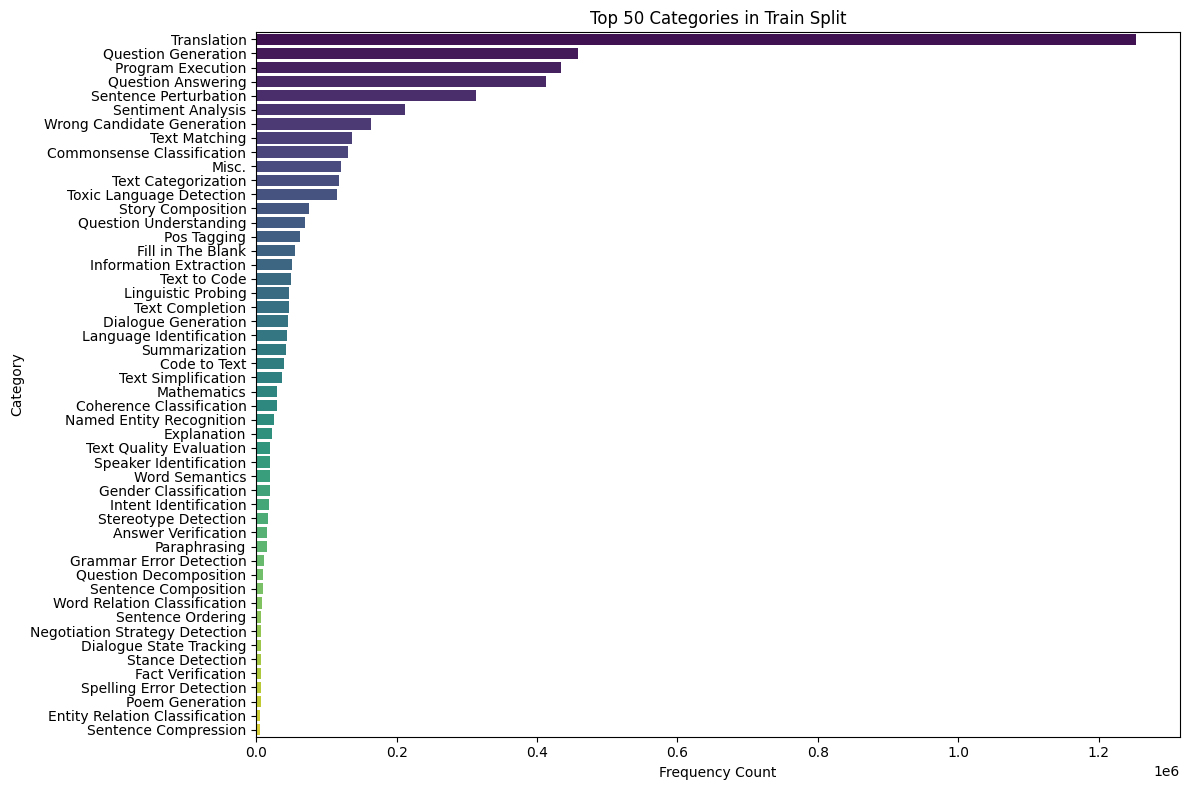

Fetching category distribution for test split...

--- TEST SPLIT CATEGORY TOP 50 ---
Cause Effect Classification: 18067 (49.59%)
Textual Entailment: 11388 (31.26%)
Answerability Classification: 6503 (17.85%)
Title Generation: 474 (1.30%)


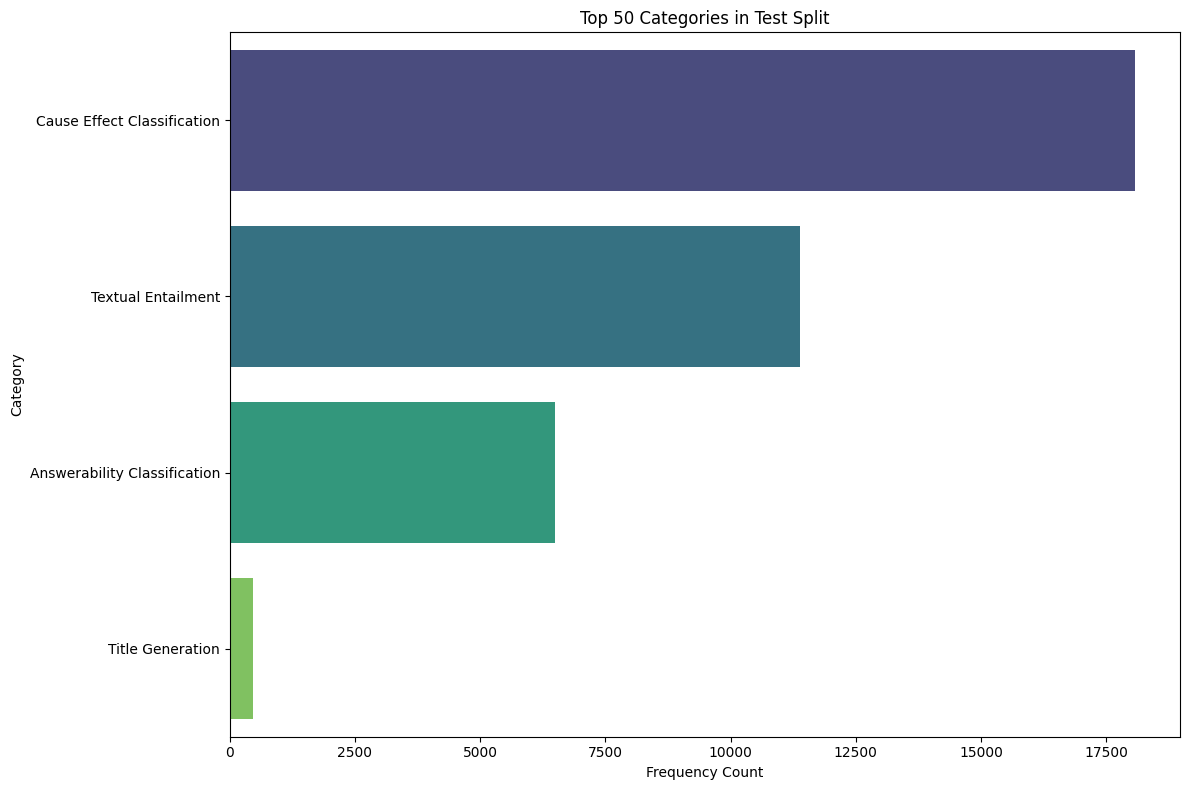

In [8]:
def analyze_and_plot_categories(split, top_n=50):
    category_counts = Counter()
    
    # Select only the column we need for performance
    subset = dataset[split].select_columns(['categories'])
    
    print(f"Fetching category distribution for {split} split...")
    
    # Iterate through the streaming dataset in batches
    for batch in subset.iter(batch_size=1000):
        # Handle cases where 'categories' is a list of strings or a single string per instance
        for cats in batch['categories']:
            if isinstance(cats, list):
                category_counts.update(cats)
            else:
                category_counts.update([cats])
                
    print(f"\n--- {split.upper()} SPLIT CATEGORY TOP {top_n} ---")
    total_samples = sum(category_counts.values())
    
    # Print numerical distribution for top N
    for cat, count in category_counts.most_common(top_n):
        percentage = (count / total_samples) * 100
        print(f"{cat}: {count} ({percentage:.2f}%)")
        
    # Plotting the distribution
    top_cats = category_counts.most_common(top_n)
    categories_labels = [cat[0] for cat in top_cats]
    counts = [cat[1] for cat in top_cats]
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=counts, y=categories_labels, hue=categories_labels, palette="viridis", legend=False)
    plt.title(f"Top {top_n} Categories in {split.capitalize()} Split")
    plt.xlabel("Frequency Count")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()
        
    return category_counts

# Run the analysis and visualization on both splits
train_categories = analyze_and_plot_categories("train")
test_categories = analyze_and_plot_categories("test")

### Distribution of Hard Prompt (Definition) Length (in terms of Tokens)

Calculating token lengths for train split...


  0%|          | 0/4903 [00:00<?, ?it/s]

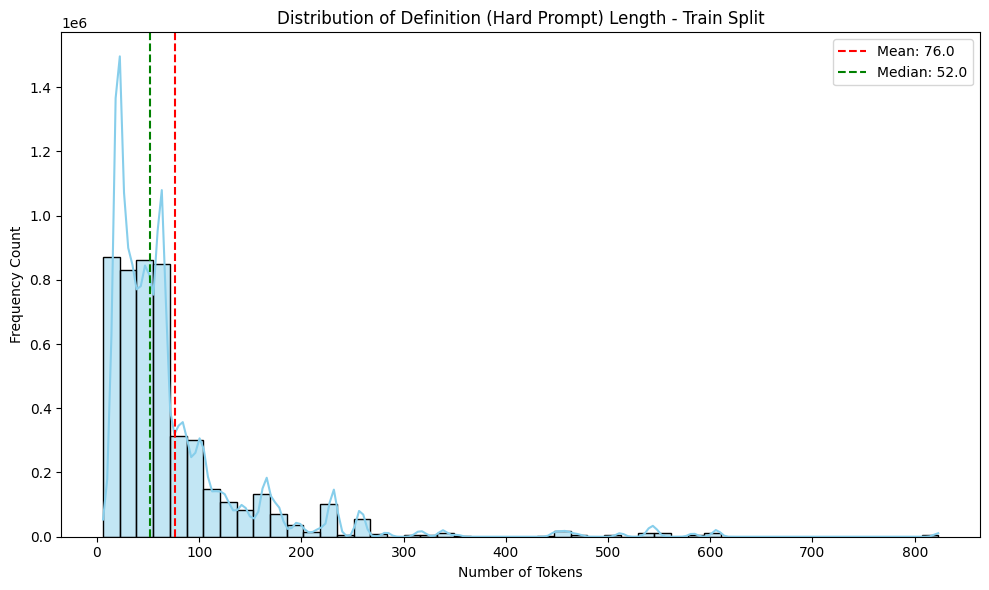

--- TRAIN SPLIT LENGTH STATS ---
Total instances analyzed: 4902436
Min length: 6
Max length: 823
Mean length: 76.00
Median length: 52.00
95th percentile: 231.00
Calculating token lengths for test split...


  0%|          | 0/4903 [00:00<?, ?it/s]

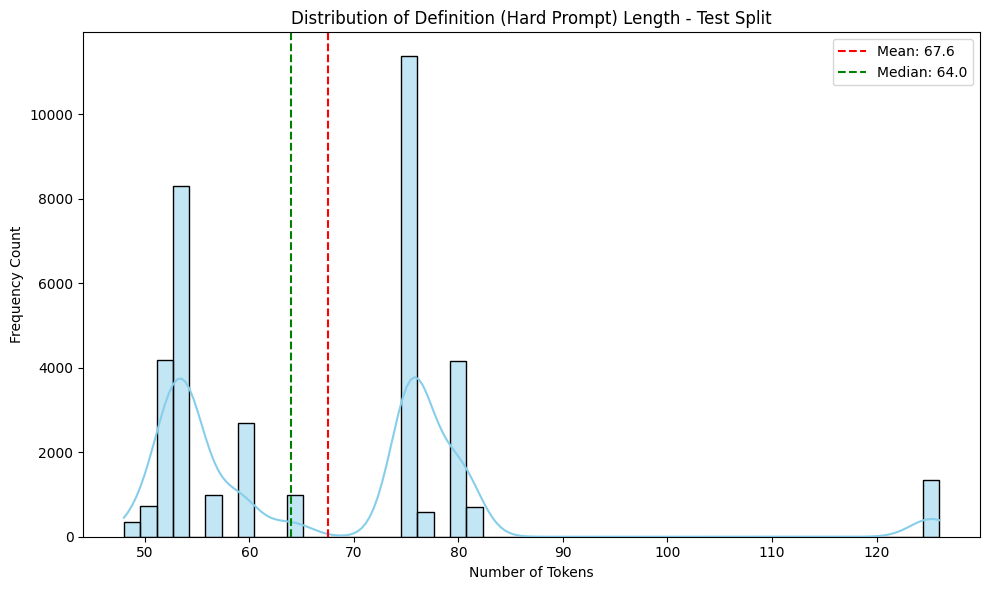

--- TEST SPLIT LENGTH STATS ---
Total instances analyzed: 36432
Min length: 48
Max length: 126
Mean length: 67.56
Median length: 64.00
95th percentile: 81.00


In [9]:
# Initialize Llama tokenizer
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

def plot_definition_length_distribution(split):
    token_lengths = []
    
    # Select only the 'instruction' column
    subset = dataset[split].select_columns(['instruction'])
    
    print(f"Calculating token lengths for {split} split...")
    
    # Iterate through the streaming dataset in batches
    for batch in tqdm(subset.iter(batch_size=1000), total = math.ceil(4902436 / 1000)):
        for instruction in batch['instruction']:
            
            # Tokenize without truncation to get the true length
            tokens = tokenizer(instruction, truncation=False, add_special_tokens=False)['input_ids']
            token_lengths.append(len(tokens))
            
    # Plotting the distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(token_lengths, bins=50, kde=True, color='skyblue')
    
    # Calculate mean and median
    mean_len = np.mean(token_lengths)
    median_len = np.median(token_lengths)
    
    # Add vertical lines for mean and median
    plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_len:.1f}')
    plt.axvline(median_len, color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {median_len:.1f}')
    
    plt.title(f"Distribution of Definition (Hard Prompt) Length - {split.capitalize()} Split")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Frequency Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"--- {split.upper()} SPLIT LENGTH STATS ---")
    print(f"Total instances analyzed: {len(token_lengths)}")
    print(f"Min length: {np.min(token_lengths)}")
    print(f"Max length: {np.max(token_lengths)}")
    print(f"Mean length: {mean_len:.2f}")
    print(f"Median length: {median_len:.2f}")
    print(f"95th percentile: {np.percentile(token_lengths, 95):.2f}")
    
    return token_lengths

# Run the analysis on both splits
train_lengths = plot_definition_length_distribution("train")
test_lengths = plot_definition_length_distribution("test")

### TODOs
1. Are all instructions in English? --> Always English
2. What metric we need to use to figure out the quality of soft prompt elicitation? (Cosine Similarity with Contrastive Learning)
3. Viz distribution of Categories?
4. Easy vs Hard Tasks? Distribution?
5. Distribution of Hard prompt (Definition) length?